# Exploratory Data Analysis (EDA) - Diabetes Dataset

This notebook presents an Exploratory Data Analysis of the Diabetes dataset.
The objective is to explore relationships between medical attributes such as BMI, blood pressure, and other physiological variables in order to understand patterns associated with diabetes progression.

- **Dataset:** Diabetes Dataset
- **Tools Used:** Python, Matplotlib, Seaborn, Pandas, NumPy
- **Author:** Vijiyalakshmi Rajeshkymar

## Feature Description
The dataset contains the following features:

- **age:** Age of the patient
- **sex:** Gender of the patient
- **bmi:** Body Mass Index (measure of body fat)
- **bp:** Average blood pressure
- **s1-s6:** Blood serum measurements (various biochemical indicators)
- **progression:** Diabetes disease progression after one year

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135


In [3]:
# Dataset overview
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          442 non-null    float64
 1   sex          442 non-null    float64
 2   bmi          442 non-null    float64
 3   bp           442 non-null    float64
 4   s1           442 non-null    float64
 5   s2           442 non-null    float64
 6   s3           442 non-null    float64
 7   s4           442 non-null    float64
 8   s5           442 non-null    float64
 9   s6           442 non-null    float64
 10  Progression  442 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-4.524887e-12,-1.402715e-10,1.131222e-11,-1.447964e-10,5.023634e-19,-6.334842e-11,-3.767725e-19,-1.809955e-11,-2.262443e-11,-2.036199e-11,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## Data Cleaning

In [4]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Replace unrealistic zero values with median
cols_with_zero = ['bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
df[cols_with_zero] = df[cols_with_zero].replace(0, df[cols_with_zero].median())

- Column names were standardized by removing extra space and converting them to lowercase.
- Certain variables contained zero values that are not medically realistic. These values were treated as missing and replaced with the median of the respective columns to maintain data integrity.

## Missing Data Anaylsis

In [5]:
# Check for missing (null) values
df.isnull().sum()

age            0
sex            0
bmi            0
bp             0
s1             0
s2             0
s3             0
s4             0
s5             0
s6             0
progression    0
dtype: int64

- The dataset was checked for missing (null) values using the isnull() function.
- No missing values were found in any of the columns. However, some variables contained zero values that are not medically realistic (such as BMI and blood pressure).
- These values were treated as missing data and handled separately during the data cleaning process.

## Age Distribution

This histogram shows the distribution of patient ages in the dataset.

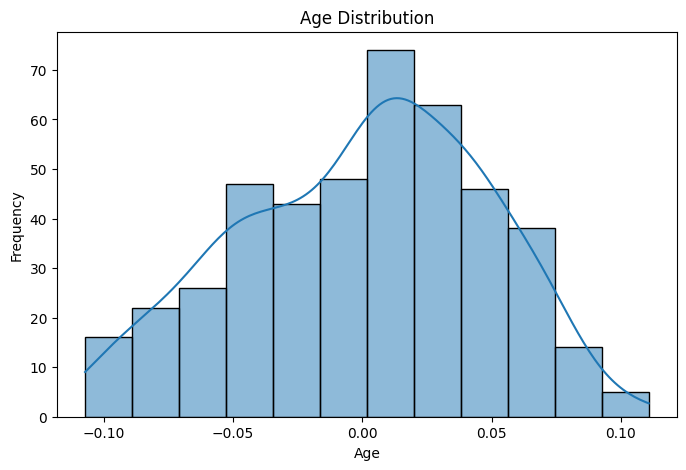

In [6]:
# Histogram to visualize the distribution of patient ages
plt.figure(figsize=(8,5))

sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Most patients fall between the ages of **40 and 60**, indicating that the dataset primarily represents **middle-aged to older adults.**

## BMI Distribution

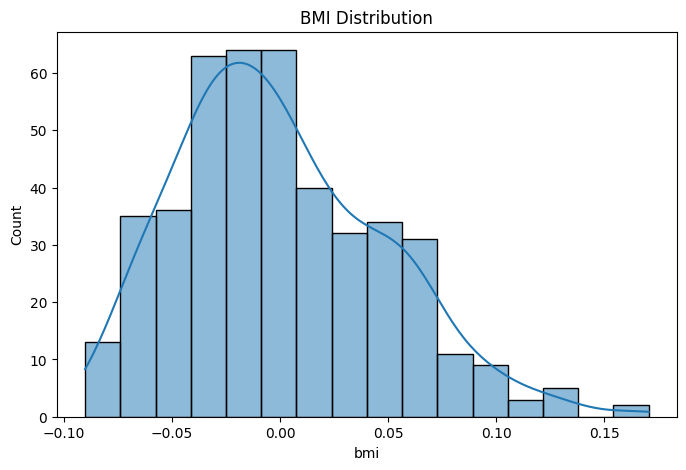

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

- The BMI distribution shows a roughly normal pattern, with most observations clustered near the mean.
- This indicates that extreme BMI values are relatively rare, while the majority of patients fall within a moderate BMI range.

## Diabetes Progression Distribution

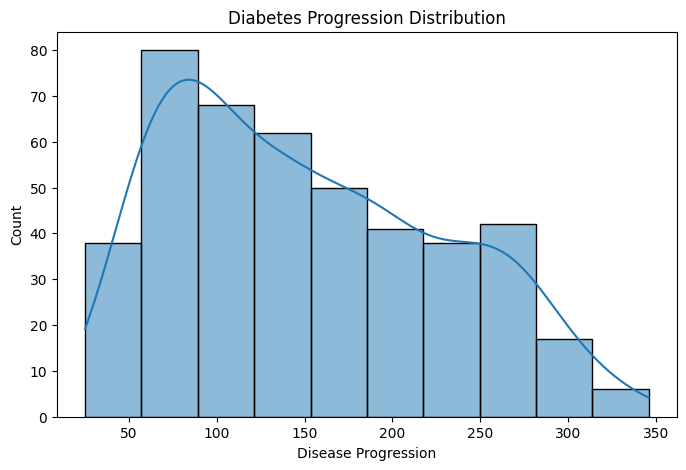

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['progression'], kde=True)
plt.title("Diabetes Progression Distribution")
plt.xlabel("Disease Progression")
plt.ylabel("Count")
plt.show()

- The distribution of diabetes progression is slightly right-skewed, with most patients having progression values **50 and 200.**
- Higher progression values above **250** occur less frequently, indicating that severe disease progression is less common in the dataset.

## BMI vs Diabetes Progression

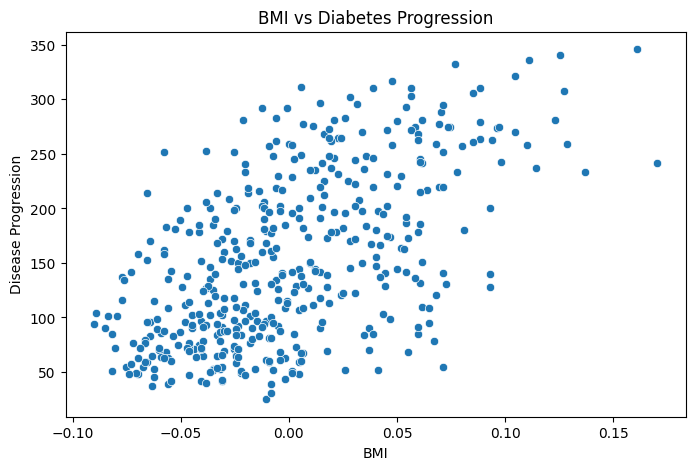

In [9]:
plt.figure(figsize=(8,5))
# Scatter plot to analyze relationship between BMI and diabetes progression
sns.scatterplot(x='bmi', y='progression', data=df)
plt.title("BMI vs Diabetes Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.show()

- The scatter plot suggests a mild positive relationship between BMI and diabetes progression.
- While higher BMI values are sometimes associated with higher progression scores, the data points are widely scattered, indicating that BMI alone may not strongly predict disease progression.

## Age vs Diabetes Progression

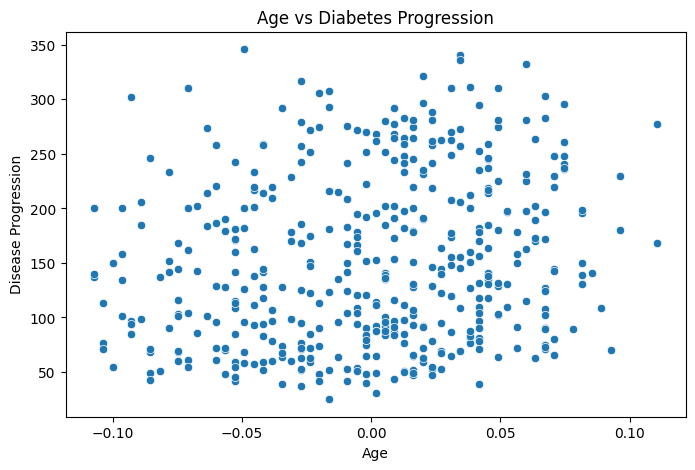

In [10]:
plt.figure(figsize=(8,5))
# Scatter plot to analyze relationship between age and diabetes progression
sns.scatterplot(x='age', y='progression', data=df)
plt.title("Age vs Diabetes Progression")
plt.xlabel("Age")
plt.ylabel("Disease Progression")
plt.show()

- The scatter plot illustrates the relationship between age and diabetes progression.
- The distribution of points appears widely dispersed with no clear trend, indicating that age alone may not be a strong predictor of disease progression.

## Correlation Heatmap

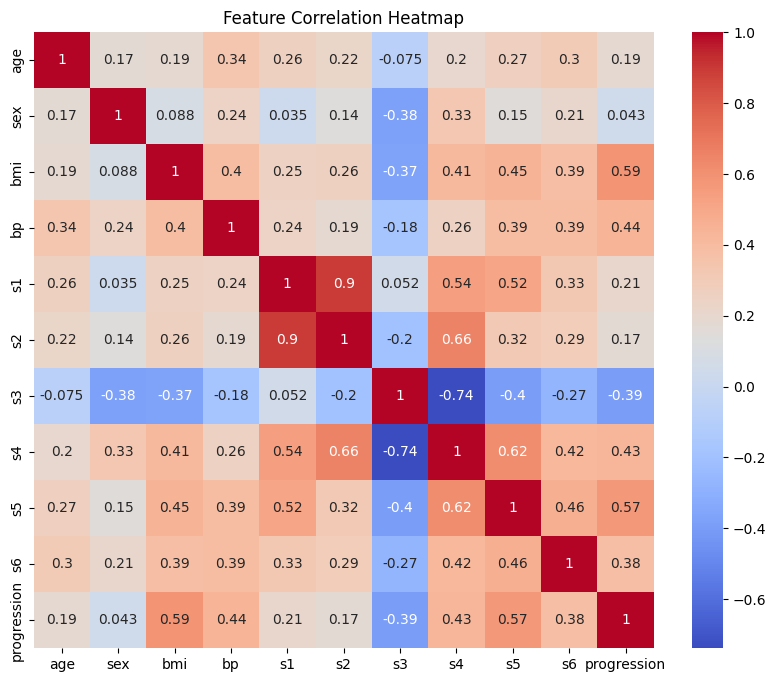

In [11]:
# Correlation heatmap to analyze relationships between variables
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

- The correlation heatmap shows that BMI and s5 have the strongest positive relationship with diabetes progression.
- BMI represents body fat, while s5 is a blood serum measurement related to metabolic activity. Blood pressure (BP) also shows a moderate correlation with the target varible.
- These findings suggest that metabolic and physiological factors play an important role in diabetes progression.

## Pairplot

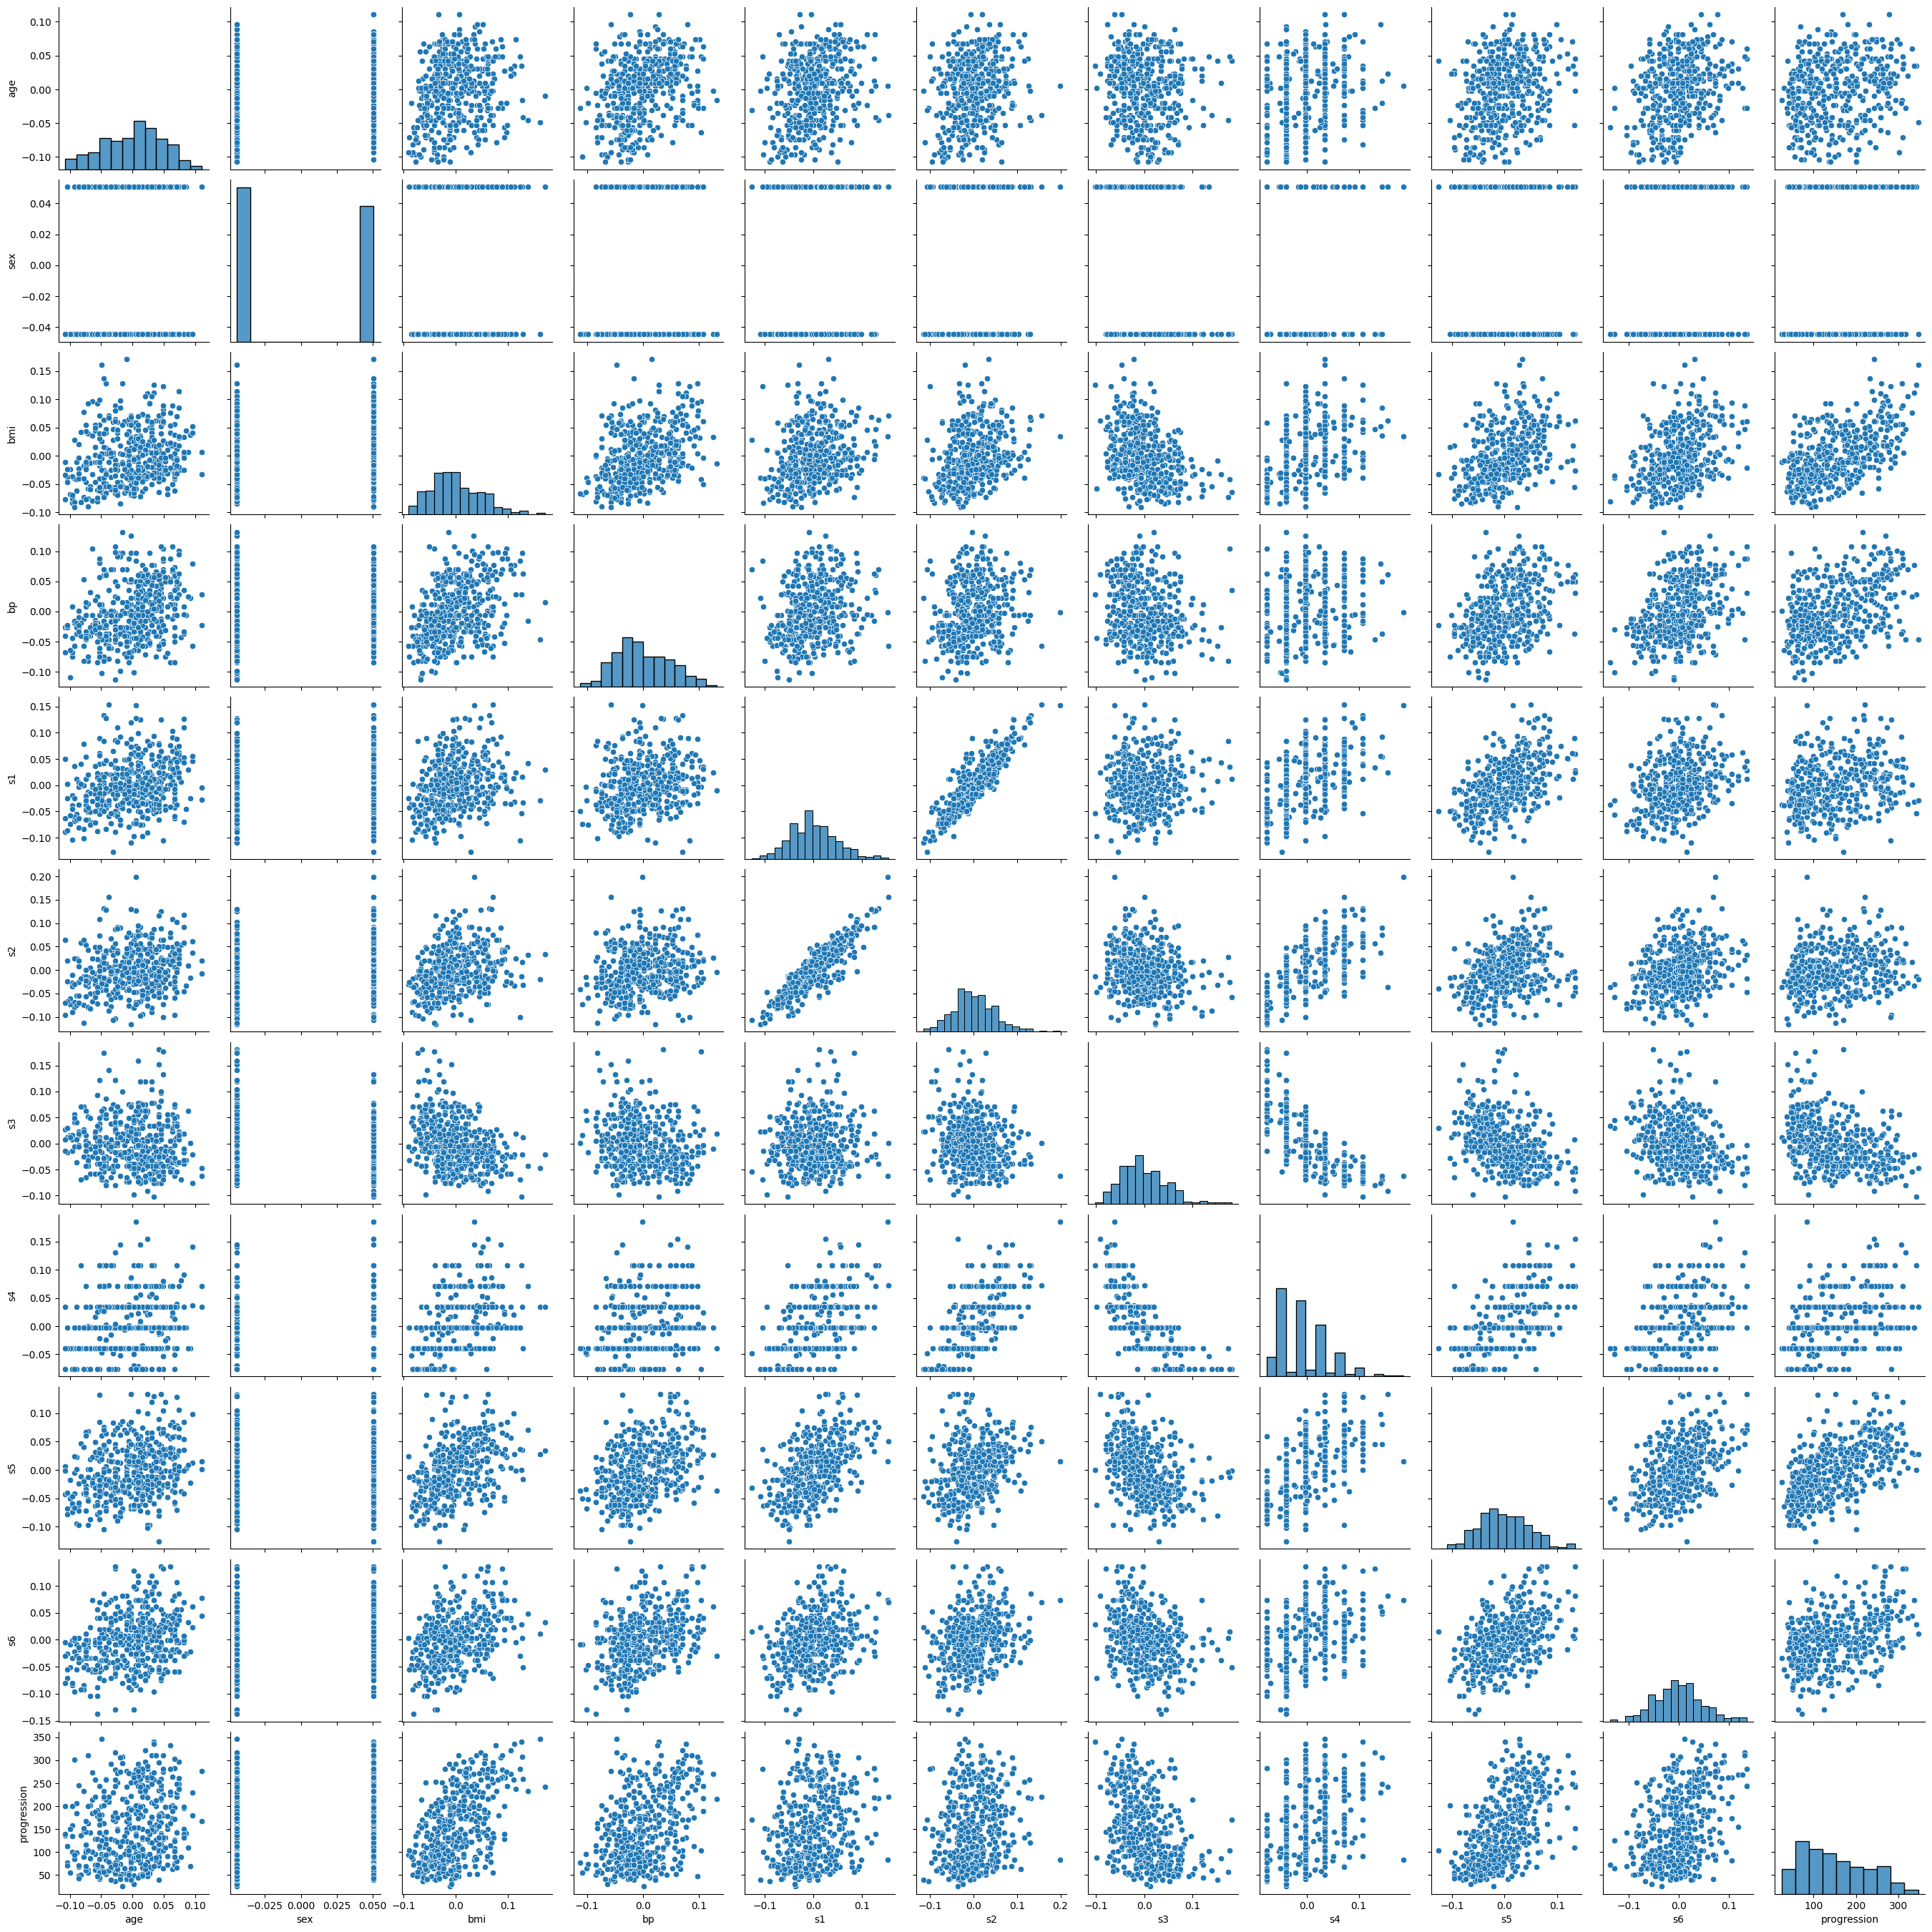

In [12]:
sns.pairplot(df)
plt.show()

- The pairplot illustrates pairwise relationships between all numerical variables in the dataset.
- It helps identify patterns and correlations among features and provides insight into how variables such as BMI and blood pressure relate to diabetes progression.

## Key Findings

1. BMI shows one of the strongest positive correlations with diabetes progression.
2. Feature s5 also has a strong relationship with disease progression.
3. Blood pressure (bp) shows a moderate positive correlation with the progression variable.
4. Age and sex have relatively weak relationships with diabetes progression compared to other features.

## Conclusion

The exploratory data analysis of the diabetes dataset shows that BMI, s5, and blood pressure are among the most important variables associated with diabetes progression. The correlation analysis indicates that these features have stronger relationships with the progression outcome compared to age and sex. These insights suggest that physiological and metabolic factors play an important role in diabetes disease progression.

Future work could involve developing predictive machine learning models to estimate diabetes progression using these features.

## Author

This report was written by: **Vijiyalakshmi Rajeshkumar**